# Clustering de Municipios - Analisis No Supervisado

Este notebook aplica K-Means y clustering jerarquico para agrupar municipios por perfil de incidencia delictiva.

## 1. Importaciones y Configuracion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

RAW = Path("../data/raw")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Consolidacion de Datos a Nivel Municipal

In [3]:
# Cargar incidencia delictiva
df_delitos = pd.read_csv(RAW / "incidencia_delictiva/2024.csv", encoding="utf-8-sig")
meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
         "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

df_delitos['total_delitos'] = df_delitos[meses].sum(axis=1)
delitos_mun = df_delitos.groupby('Cve. Municipio')['total_delitos'].sum().reset_index()
delitos_mun.columns = ['CVE_MUN', 'Total_Delitos_2024']

# Diversidad de delitos
div_delitos = df_delitos.groupby('Cve. Municipio')['Tipo de delito'].nunique().reset_index()
div_delitos.columns = ['CVE_MUN', 'Diversidad_Delitos']

# Delitos violentos
violentos = df_delitos[df_delitos['Tipo de delito'].isin(['Homicidio', 'Lesiones', 'Robo'])].copy()
violentos['total'] = violentos[meses].sum(axis=1)
delitos_violentos = violentos.groupby('Cve. Municipio')['total'].sum().reset_index()
delitos_violentos.columns = ['CVE_MUN', 'Delitos_Violentos_2024']

df_cluster = delitos_mun.merge(div_delitos, on='CVE_MUN').merge(delitos_violentos, on='CVE_MUN', how='left')
df_cluster['Delitos_Violentos_2024'] = df_cluster['Delitos_Violentos_2024'].fillna(0)

print(f"Delitos por municipio: {df_cluster.shape}")

Delitos por municipio: (74, 4)


## 3. Agregar Poblacion

In [5]:
# Poblacion 2024
df_pob = pd.read_excel(RAW / "proyecciones_poblacion/Indicadores demográficos 1990 - 2040.xlsx", sheet_name="Sheet 1")
df_pob_2024 = df_pob[df_pob['AÑO'] == 2024][['CLAVE', 'NOM_MUN', 'POB_MIT_MUN', 'EDAD_MED', 'RAZ_DEP']].copy()
df_pob_2024.columns = ['CVE_MUN', 'NOM_MUN', 'Poblacion_2024', 'Edad_Mediana', 'Razon_Dependencia']

df_cluster = df_cluster.merge(df_pob_2024, on='CVE_MUN', how='left')

# Tasas per capita
df_cluster['Tasa_Delitos_100k'] = (df_cluster['Total_Delitos_2024'] / df_cluster['Poblacion_2024']) * 100000
df_cluster['Tasa_Violentos_100k'] = (df_cluster['Delitos_Violentos_2024'] / df_cluster['Poblacion_2024']) * 100000

print(f"Dataset con poblacion: {df_cluster.shape}")

Dataset con poblacion: (74, 10)


## 4. Agregar Marginacion

In [7]:
# Marginacion 2020
df_margi = pd.read_excel(RAW / "marginacion_municipal/Indice de marginación por municipio 2020.xlsx", sheet_name="IMM_2020")
df_margi_subset = df_margi[['CVE_MUN', 'IM_2020', 'IMN_2020', 'ANALF', 'SBASC', 'PO2SM']].copy()

df_cluster = df_cluster.merge(df_margi_subset, on='CVE_MUN', how='left')

print(f"Dataset con marginacion: {df_cluster.shape}")

Dataset con marginacion: (74, 15)


## 5. Agregar Zonas Salva

In [8]:
# Zonas Salva
df_salva = pd.read_excel(RAW / "zonas_salva/Zonas Salva enero 2026.xlsx", sheet_name="ENERO 2026")
salva_mun = df_salva['MUNICIPIO'].value_counts().reset_index()
salva_mun.columns = ['NOM_MUN', 'Num_Zonas_Salva']

df_cluster['NOM_MUN'] = df_cluster['NOM_MUN'].str.upper()
df_cluster = df_cluster.merge(salva_mun, on='NOM_MUN', how='left')
df_cluster['Num_Zonas_Salva'] = df_cluster['Num_Zonas_Salva'].fillna(0)
df_cluster['Zonas_Salva_100k'] = (df_cluster['Num_Zonas_Salva'] / df_cluster['Poblacion_2024']) * 100000

print(f"Dataset final consolidado: {df_cluster.shape}")
print(df_cluster.head())

Dataset final consolidado: (74, 17)
   CVE_MUN  Total_Delitos_2024  Diversidad_Delitos  Delitos_Violentos_2024  \
0    26001                  13                  40                       4   
1    26002                 682                  40                      95   
2    26003                 149                  40                      41   
3    26004                  81                  40                      28   
4    26005                  26                  40                      11   

       NOM_MUN  Poblacion_2024  Edad_Mediana  Razon_Dependencia  \
0      ACONCHI          2600.0          35.0              58.54   
1  AGUA PRIETA         98528.0          28.0              47.88   
2       ALAMOS         25132.0          33.0              60.70   
3        ALTAR          9714.0          27.0              56.17   
4     ARIVECHI          1225.0          39.0              64.87   

   Tasa_Delitos_100k  Tasa_Violentos_100k    IM_2020  IMN_2020     ANALF  \
0         500.00

## 6. Preparacion de Variables para Clustering

In [9]:
variables_cluster = [
    'Tasa_Delitos_100k',
    'Tasa_Violentos_100k',
    'Diversidad_Delitos',
    'IM_2020',
    'Edad_Mediana',
    'ANALF',
    'PO2SM',
    'Zonas_Salva_100k'
]

print("Valores nulos:")
print(df_cluster[variables_cluster].isnull().sum())

df_cluster_clean = df_cluster[variables_cluster + ['CVE_MUN', 'NOM_MUN']].dropna()
print(f"\nMunicipios para clustering: {len(df_cluster_clean)}")

Valores nulos:
Tasa_Delitos_100k      2
Tasa_Violentos_100k    2
Diversidad_Delitos     0
IM_2020                2
Edad_Mediana           2
ANALF                  2
PO2SM                  2
Zonas_Salva_100k       2
dtype: int64

Municipios para clustering: 72


## 7. Estandarizacion de Variables

Se aplica StandardScaler para llevar todas las variables a media 0 y desviacion estandar 1. Esto es esencial en clustering para que variables con mayor magnitud (ej. poblacion) no dominen sobre variables pequenas (ej. edad mediana).

In [11]:
# Estandarizacion de Variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_clean[variables_cluster])
print("Variables estandarizadas")

Variables estandarizadas


Varianza explicada por componentes: [0.32612473 0.25649558]


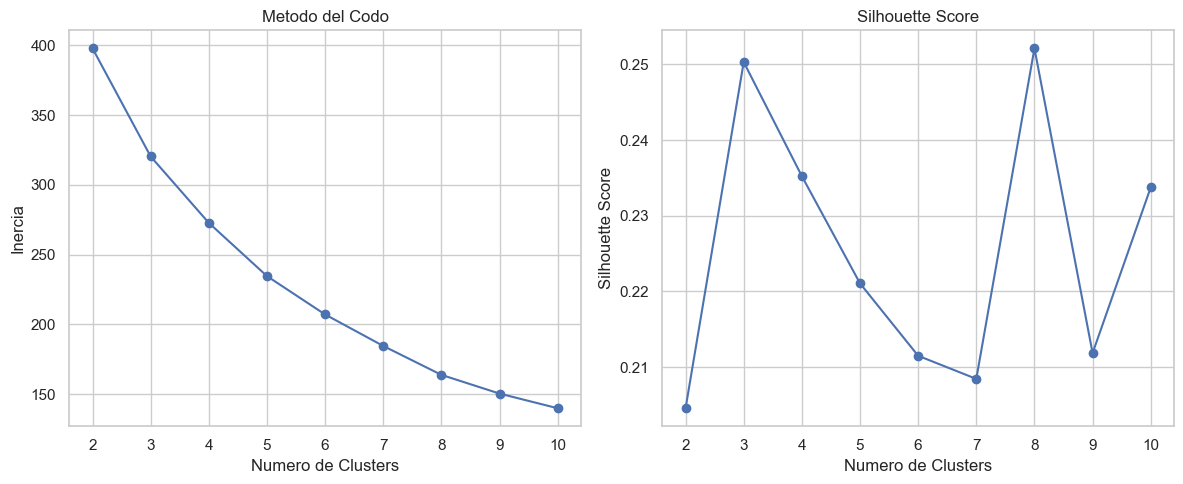

Numero optimo de clusters: 8


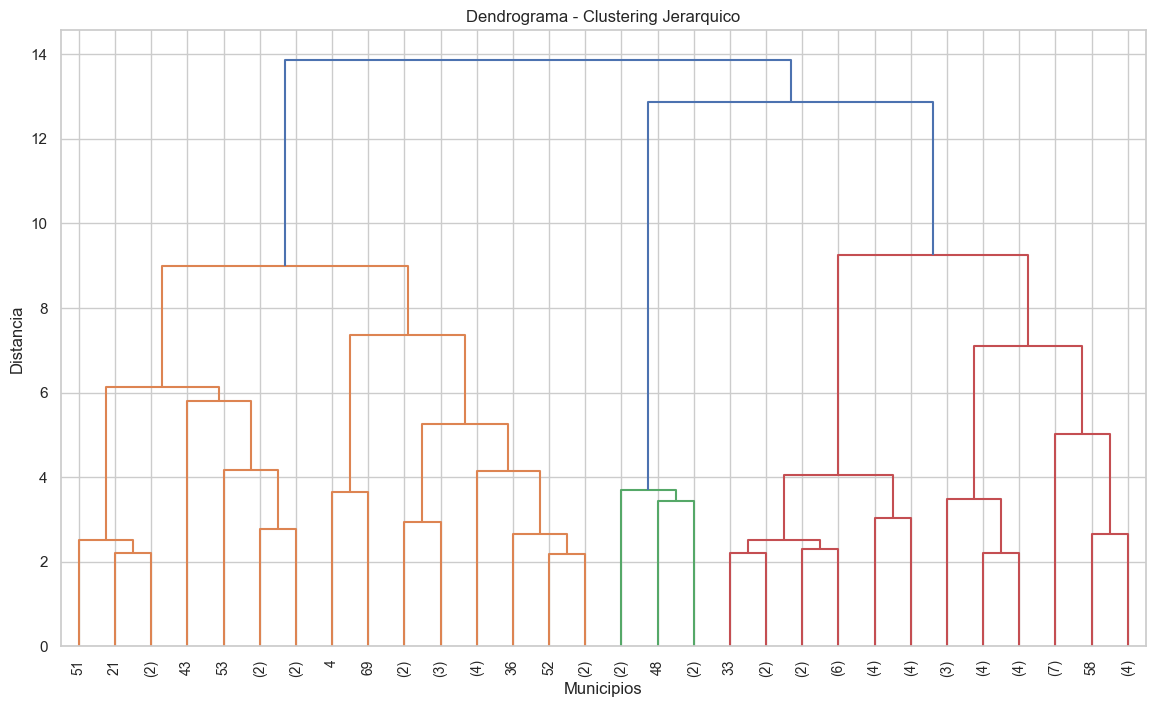

Coincidencia entre metodos: 0.0%

Cluster 1:
  Municipios: 14
  Tasa Delitos media: 750.2
  Diversidad Delitos media: 40.0
  IM_2020 media: 57.0

Cluster 2:
  Municipios: 20
  Tasa Delitos media: 399.5
  Diversidad Delitos media: 40.0
  IM_2020 media: 56.8

Cluster 3:
  Municipios: 17
  Tasa Delitos media: 1006.9
  Diversidad Delitos media: 40.0
  IM_2020 media: 58.7

Cluster 4:
  Municipios: 8
  Tasa Delitos media: 1135.0
  Diversidad Delitos media: 40.0
  IM_2020 media: 56.6

Cluster 5:
  Municipios: 5
  Tasa Delitos media: 879.1
  Diversidad Delitos media: 40.0
  IM_2020 media: 52.9

Cluster 6:
  Municipios: 1
  Tasa Delitos media: 1126.8
  Diversidad Delitos media: 40.0
  IM_2020 media: 57.2

Cluster 7:
  Municipios: 2
  Tasa Delitos media: 2159.3
  Diversidad Delitos media: 40.0
  IM_2020 media: 57.1

Cluster 8:
  Municipios: 5
  Tasa Delitos media: 722.3
  Diversidad Delitos media: 40.0
  IM_2020 media: 58.1
RESUMEN - CLUSTERING DE MUNICIPIOS

METODOS APLICADOS
  - K-Means: 8 clu

In [12]:
# PCA para reduccion de dimensionalidad
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada por componentes: {pca.explained_variance_ratio_}")

# Encontrar numero optimo de clusters
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Graficas para determinar k optimo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Metodo del Codo')
plt.xlabel('Numero de Clusters')
plt.ylabel('Inercia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouettes, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Numero de Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Seleccionar k optimo basado en silhouette maximo
k_optimo = k_range[np.argmax(silhouettes)]
print(f"Numero optimo de clusters: {k_optimo}")

# Aplicar K-Means
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster_clean['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

# Clustering Jerarquico
linkage_matrix = linkage(X_scaled, method='ward')

# Dendrograma
plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendrograma - Clustering Jerarquico')
plt.xlabel('Municipios')
plt.ylabel('Distancia')
plt.show()

# Cortar dendrograma en k clusters
clusters_hier = fcluster(linkage_matrix, k_optimo, criterion='maxclust')
df_cluster_clean['Cluster_Hier'] = clusters_hier

# Comparacion entre metodos
coincidencia = (df_cluster_clean['Cluster_KMeans'] == df_cluster_clean['Cluster_Hier']).mean() * 100
print(f"Coincidencia entre metodos: {coincidencia:.1f}%")

# Analisis de clusters
for cluster in range(k_optimo):
    print(f"\nCluster {cluster+1}:")
    cluster_data = df_cluster_clean[df_cluster_clean['Cluster_KMeans'] == cluster]
    print(f"  Municipios: {len(cluster_data)}")
    print(f"  Tasa Delitos media: {cluster_data['Tasa_Delitos_100k'].mean():.1f}")
    print(f"  Diversidad Delitos media: {cluster_data['Diversidad_Delitos'].mean():.1f}")
    print(f"  IM_2020 media: {cluster_data['IM_2020'].mean():.1f}")

print("=" * 70)
print("RESUMEN - CLUSTERING DE MUNICIPIOS")
print("=" * 70)

print(f"""
METODOS APLICADOS
  - K-Means: {k_optimo} clusters
  - Clustering Jerarquico: dendrograma ward
  - Validacion: silhouette score, coincidencia entre metodos

HALLAZGOS
  - Se identificaron {k_optimo} perfiles municipales diferenciados
""")